# Dense autoencoder v1 vs. VAE — step by step

**Derived from:** `08_dense_v1_comparison/dense_backend.py`,
`evaluate_by_attack_type_dense.py`, `evaluate_segmented_injection_dense.py`,
`comparison_vae_vs_dense.md`.

**Model:** Dense autoencoder v1 (full_features),
`phase3_dense/04_phase3_models/full_features` (5 seeds). Threshold_95 is
**not** a saved file for this model — it's computed fresh per seed as the
95th percentile of reconstruction error on `phase3_dense`'s own
validation-split benign flows (see `dense_backend.py`'s docstring for why).

**Data:** the same `test_with_attack_type.csv` / `segmented_sequence.csv`
flows and the same 18 `_scaled` feature columns as the VAE notebooks — Dense
v1 was trained directly on those columns with no separate refit scaler.

Same structure as notebooks 1-2, run against `DenseBackend` instead of
`VAEBackend`, so results are directly comparable step for step.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display as ipy_display
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = "/Users/mustafa/Desktop/NIDS/IDS-Project"
ATTACK_TYPE_DIR = os.path.join(PROJECT_ROOT, "06_attack_type_analysis")
SEGMENTED_DIR = os.path.join(PROJECT_ROOT, "07_segmented_injection")
DENSE_DIR = os.path.join(PROJECT_ROOT, "08_dense_v1_comparison")
REPORT_DIR = os.path.join(PROJECT_ROOT, "10_final_report")
sys.path.insert(0, ATTACK_TYPE_DIR)
sys.path.insert(0, SEGMENTED_DIR)
sys.path.insert(0, DENSE_DIR)
import evaluate_by_attack_type as single
import evaluate_pairwise_attack_type as pairwise
import evaluate_segmented_injection as seg
import dense_backend
from dense_backend import DEFAULT_DENSE_BACKEND, MODEL_LABEL, MODEL_DIR_DESC

%matplotlib inline
pd.set_option("display.width", 160)
print("Modules loaded:", dense_backend.__file__)
print(MODEL_LABEL, "/", MODEL_DIR_DESC)

Modules loaded: /Users/mustafa/Desktop/NIDS/IDS-Project/08_dense_v1_comparison/dense_backend.py
Dense autoencoder v1 (full_features) / phase3_dense/04_phase3_models/full_features


## 1. Dense v1 model load + threshold computation

In [2]:
seed0_model = DEFAULT_DENSE_BACKEND.load(0)
seed0_model.summary()

thr95_seed0 = DEFAULT_DENSE_BACKEND.threshold(seed0_model, 0)
print(f"\\nSeed 0 threshold_95 (95th percentile of val-benign reconstruction error): {thr95_seed0:.5f}")
print(f"Backend seeds: {DEFAULT_DENSE_BACKEND.seeds}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,672 (10.44 KB)

 Trainable params: 890 (3.48 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,782 (6.96 KB)

  [DenseBackend] val-benign reference set for threshold_95: 4609 flows


\nSeed 0 threshold_95 (95th percentile of val-benign reconstruction error): 0.09268
Backend seeds: [0, 1, 2, 3, 4]


## 2. Single attack-type Dense evaluation

All 5 seeds are used (the full published seed count for this model, so there is no separate 'demo' subset here unlike the VAE notebooks).

Loading test_with_attack_type.csv (row_index/window_id/is_attack/attack_type)...
Reconstructing feature columns via row_index against the combined features_all_windows.csv + resampled-window feature tables...


Assembled eval frame: 9931 rows, 18 feature columns.


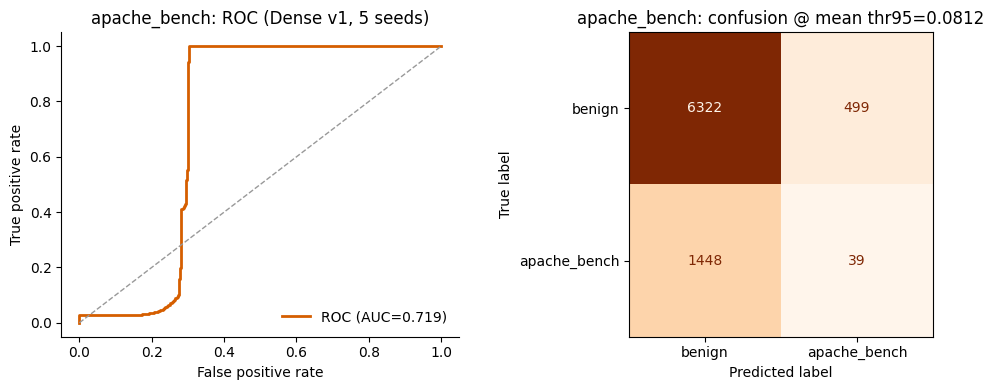

n_benign=6821 n_attack=1487 ROC-AUC=0.7191 recall@thr95=0.0262 benign_FPR@thr95=0.0732


In [3]:
feature_cols = single.load_feature_cols()
df = single.assemble_labeled_features_df(feature_cols)

def dense_single_attack_type(attack_type):
    subset = df[(df["is_attack"] == 0) | (df["attack_type"] == attack_type)].copy()
    X = subset[feature_cols].values.astype("float32")
    y = subset["is_attack"].values
    error_matrix, thresholds = single.compute_error_matrix(X, backend=DEFAULT_DENSE_BACKEND)
    mean_error = error_matrix.mean(axis=0)
    mean_thr = float(np.mean(thresholds))
    fpr, tpr, _ = roc_curve(y, mean_error)
    roc_auc = auc(fpr, tpr)
    pred = (mean_error > mean_thr).astype(int)
    cm = confusion_matrix(y, pred)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(fpr, tpr, color="#D55E00", linewidth=2, label=f"ROC (AUC={roc_auc:.3f})")
    axes[0].plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1)
    axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
    axes[0].set_title(f"{attack_type}: ROC (Dense v1, 5 seeds)")
    axes[0].legend(frameon=False); axes[0].spines[["top", "right"]].set_visible(False)

    ConfusionMatrixDisplay(cm, display_labels=["benign", attack_type]).plot(ax=axes[1], colorbar=False, cmap="Oranges")
    axes[1].set_title(f"{attack_type}: confusion @ mean thr95={mean_thr:.4f}")
    fig.tight_layout()
    plt.show()
    print(f"n_benign={int((y==0).sum())} n_attack={int((y==1).sum())} ROC-AUC={roc_auc:.4f} "
          f"recall@thr95={pred[y==1].mean():.4f} benign_FPR@thr95={pred[y==0].mean():.4f}")

dense_single_attack_type("apache_bench")

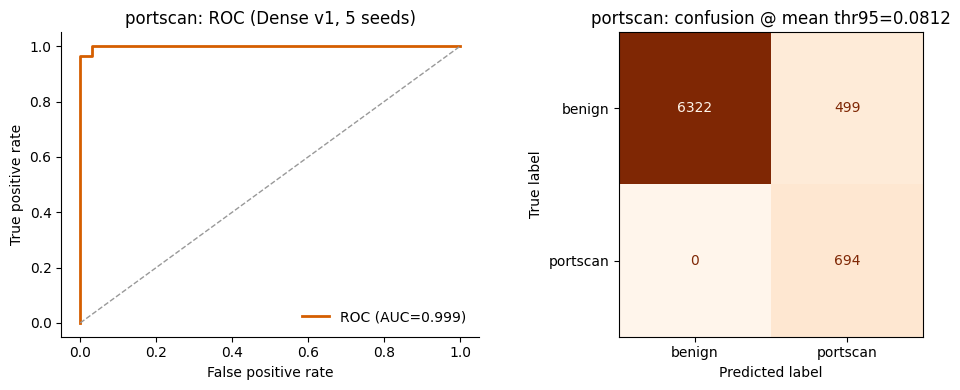

n_benign=6821 n_attack=694 ROC-AUC=0.9990 recall@thr95=1.0000 benign_FPR@thr95=0.0732


In [4]:
dense_single_attack_type("portscan")

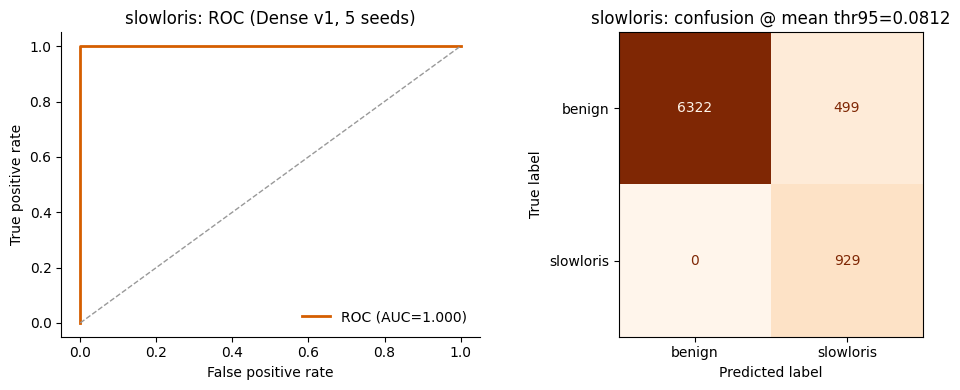

n_benign=6821 n_attack=929 ROC-AUC=1.0000 recall@thr95=1.0000 benign_FPR@thr95=0.0732


In [5]:
dense_single_attack_type("slowloris")

## 3. Pairwise Dense evaluation — pooled vs. decomposed recall


=== portscan+apache_bench: n_benign=6821, n_attack=2181 ===


  mean over 5 seeds: ROC-AUC=0.7921 PR-AUC=0.6023 F1=0.4375 benign_FPR=0.0615 attack_recall=0.3339

=== portscan+slowloris: n_benign=6821, n_attack=1623 ===


  mean over 5 seeds: ROC-AUC=0.9995 PR-AUC=0.9981 F1=0.8840 benign_FPR=0.0615 attack_recall=0.9970

=== apache_bench+slowloris: n_benign=6821, n_attack=2416 ===


  mean over 5 seeds: ROC-AUC=0.8127 PR-AUC=0.6663 F1=0.5090 benign_FPR=0.0615 attack_recall=0.4007


,attack_recall,recall__apache_bench,recall__portscan,recall__slowloris
attack_type,,,,
apache_bench+slowloris,0.400662,0.026227,NaN,1.0
portscan+apache_bench,0.333884,0.026227,0.993084,NaN
portscan+slowloris,0.997043,NaN,0.993084,1.0


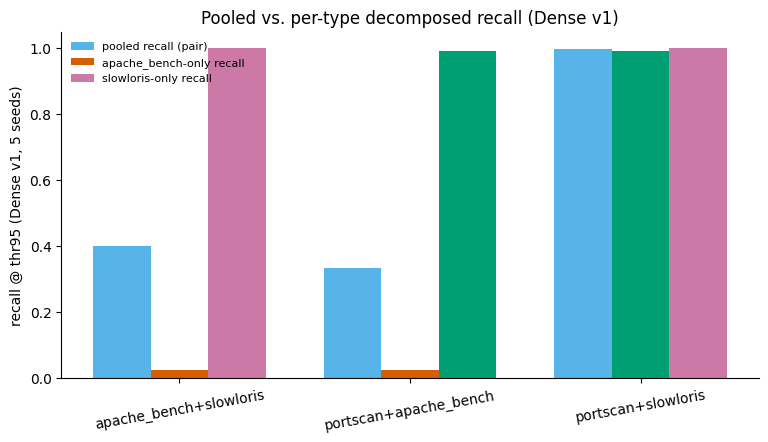

In [6]:
dense_pair_rows = []
for pair in pairwise.PAIRS:
    name = pairwise.pair_name(pair)
    subset = df[(df["is_attack"] == 0) | (df["attack_type"].isin(pair))].copy()
    dense_pair_rows.extend(single.evaluate_group(subset, feature_cols, name, backend=DEFAULT_DENSE_BACKEND))
dense_pair_df = pd.DataFrame(dense_pair_rows)
recall_cols = [c for c in dense_pair_df.columns if c.startswith("recall__")]
dense_pair_summary = dense_pair_df.groupby("attack_type")[["attack_recall"] + recall_cols].mean()
display(dense_pair_summary)

fig, ax = plt.subplots(figsize=(9, 4.5))
pairs = dense_pair_summary.index.tolist()
x = np.arange(len(pairs)); width = 0.25
ax.bar(x - width, dense_pair_summary["attack_recall"], width, label="pooled recall (pair)", color="#56B4E9")
colors_by_type = {"apache_bench": "#D55E00", "portscan": "#009E73", "slowloris": "#CC79A7"}
for i, pair_name in enumerate(pairs):
    types_in_pair = [c.replace("recall__", "") for c in recall_cols if not pd.isna(dense_pair_summary.loc[pair_name, c])]
    for j, t in enumerate(types_in_pair):
        val = dense_pair_summary.loc[pair_name, f"recall__{t}"]
        ax.bar(x[i] + j*width, val, width, color=colors_by_type[t], label=f"{t}-only recall" if i == 0 else None)
ax.set_xticks(x); ax.set_xticklabels(pairs, rotation=10)
ax.set_ylabel("recall @ thr95 (Dense v1, 5 seeds)")
ax.set_title("Pooled vs. per-type decomposed recall (Dense v1)")
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. Segmented (contiguous-block) Dense evaluation

Dense v1 mean threshold_95 across 5 seeds: 0.08120


,fpr,recall
segment_label,,
apache_bench,NaN,0.026227
benign,0.061543,NaN
portscan,NaN,0.993084
slowloris,NaN,1.000000


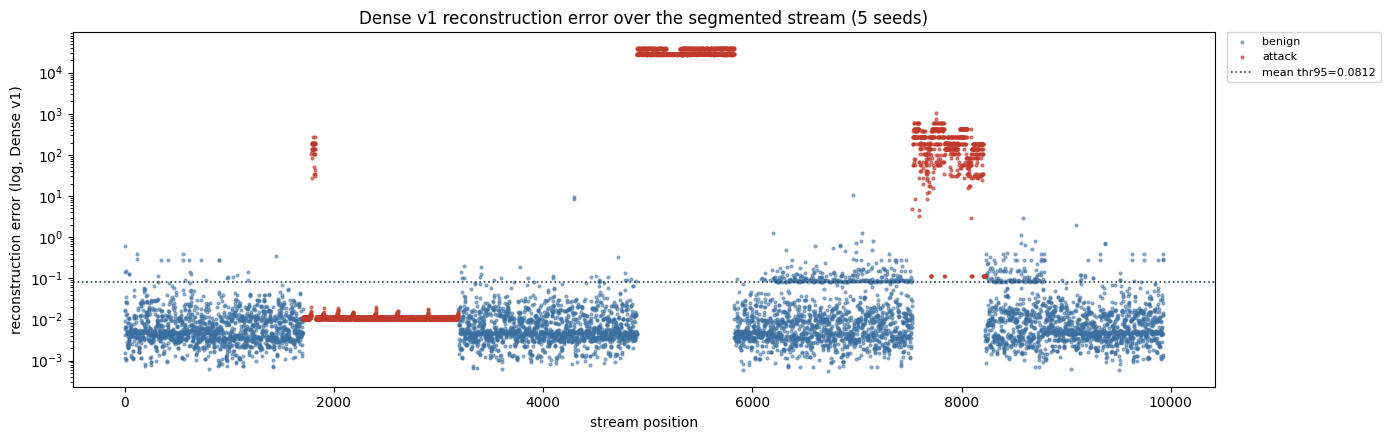

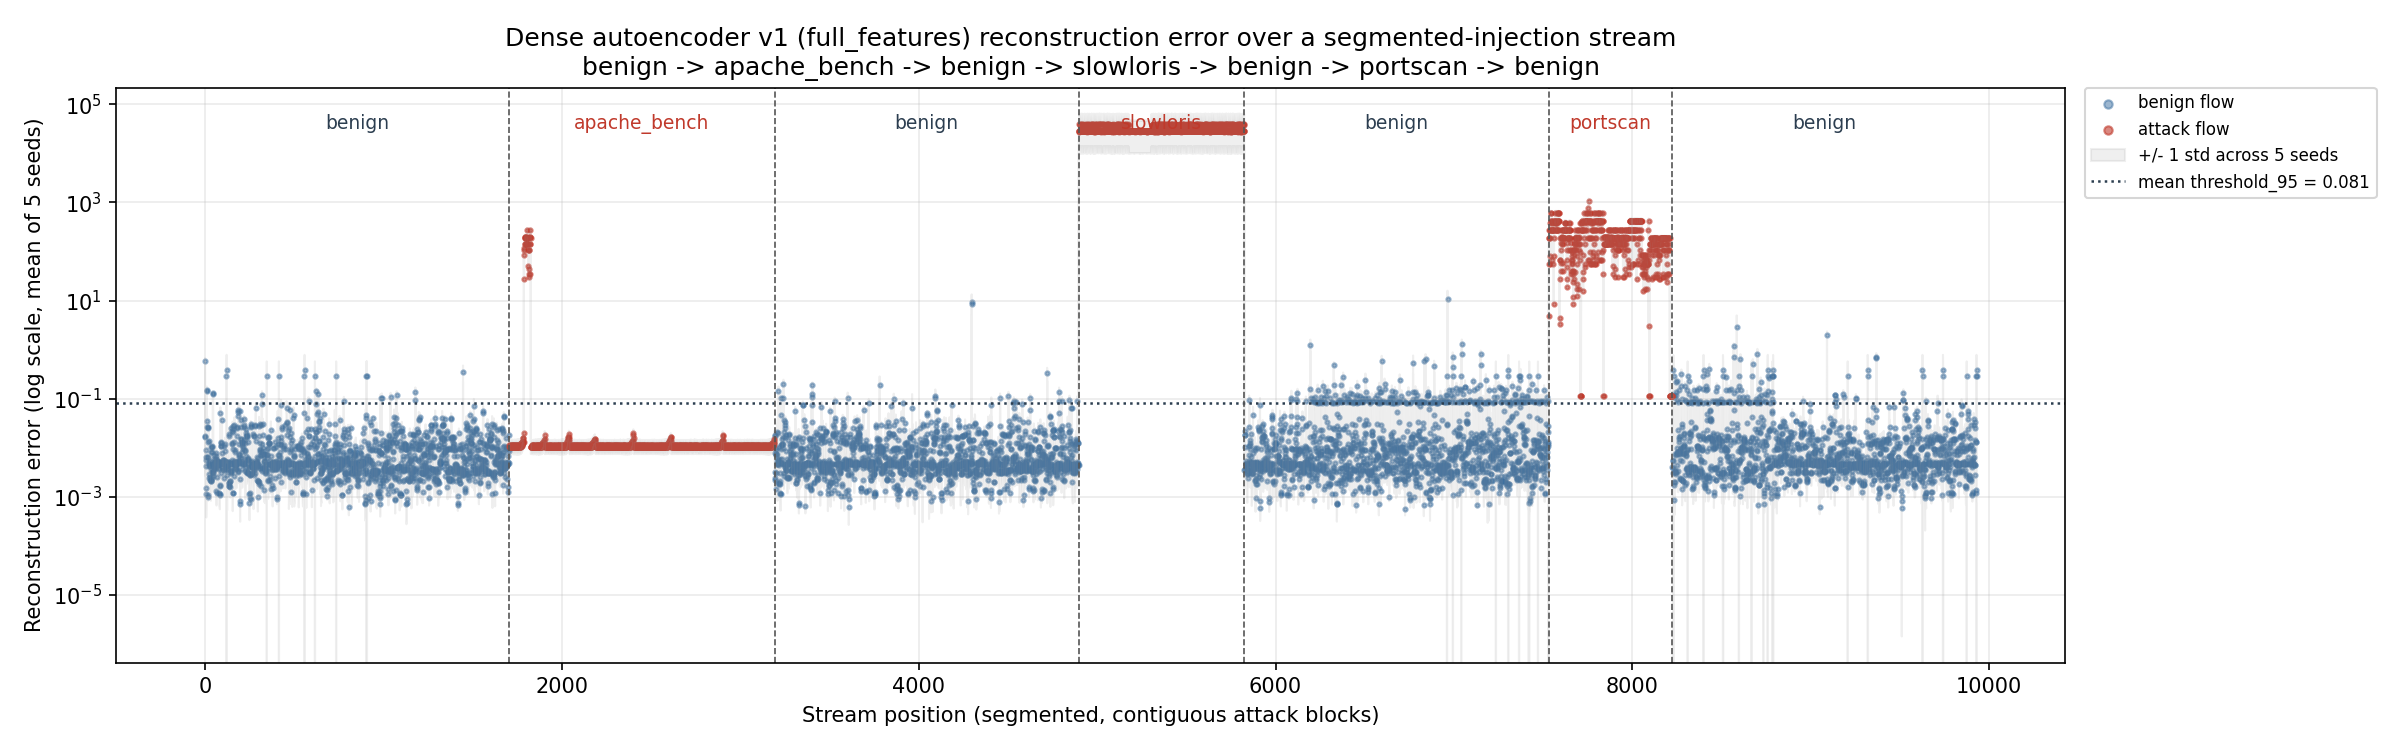

In [7]:
feature_cols = single.load_feature_cols()
ordered_df = seg.load_ordered_features(seg.SEQUENCE_PATH, feature_cols)
X_seg = ordered_df[feature_cols].values.astype("float32")
y_seg = ordered_df["is_attack"].values

error_matrix_dense, thresholds_dense = single.compute_error_matrix(X_seg, backend=DEFAULT_DENSE_BACKEND)
mean_error_dense = error_matrix_dense.mean(axis=0)
mean_thr_dense = float(np.mean(thresholds_dense))
print(f"Dense v1 mean threshold_95 across {len(DEFAULT_DENSE_BACKEND.seeds)} seeds: {mean_thr_dense:.5f}")

segments = ordered_df[["segment_id", "segment_label"]].drop_duplicates().sort_values("segment_id")
dense_seg_rows = []
for i in range(error_matrix_dense.shape[0]):
    errors_i, thr_i = error_matrix_dense[i], thresholds_dense[i]
    pred_i = (errors_i > thr_i).astype(int)
    for _, s in segments.iterrows():
        mask = (ordered_df["segment_id"] == s["segment_id"]).values
        seg_y, seg_pred = y_seg[mask], pred_i[mask]
        if s["segment_label"] == "benign":
            dense_seg_rows.append({"segment_label": s["segment_label"], "fpr": seg_pred.mean(), "recall": np.nan})
        else:
            dense_seg_rows.append({"segment_label": s["segment_label"], "fpr": np.nan, "recall": seg_pred.mean()})
dense_seg_summary = pd.DataFrame(dense_seg_rows).groupby("segment_label")[["fpr", "recall"]].mean()
display(dense_seg_summary)

fig, ax = plt.subplots(figsize=(14, 4.5))
benign_mask, attack_mask = (y_seg == 0), (y_seg == 1)
ax.scatter(ordered_df["position"][benign_mask], mean_error_dense[benign_mask], s=4, color="#3b6fa0", alpha=0.5, label="benign")
ax.scatter(ordered_df["position"][attack_mask], mean_error_dense[attack_mask], s=4, color="#c0392b", alpha=0.6, label="attack")
ax.axhline(mean_thr_dense, color="#2c3e50", linestyle=":", linewidth=1.2, label=f"mean thr95={mean_thr_dense:.4f}")
ax.set_yscale("log"); ax.set_xlabel("stream position"); ax.set_ylabel("reconstruction error (log, Dense v1)")
ax.set_title("Dense v1 reconstruction error over the segmented stream (5 seeds)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, borderaxespad=0)
fig.tight_layout()
plt.show()

ipy_display(Image(filename=os.path.join(DENSE_DIR, "segmented_injection_error_plot_dense.png")))

## 5. Final comparison: VAE vs. Dense v1, macro-average

Loaded from the canonical deterministic VAE table `10_final_report/01_single_attack_type/vae/results.csv` (z_mean scoring, audit finding O2; hybrid dedup metrics for PR-AUC/F1) and `results_single_attack_type_dense.csv` (Dense v1 — already deterministic, unchanged by O2) — the published 20-/5-seed numbers, not the demo/full-but-single-run numbers computed live above.

,attack_type,roc_auc_mean,attack_recall_mean,f1_mean,model
0,apache_bench,0.666955,0.026227,0.040983,VAE
1,portscan,0.998782,0.998271,0.768925,VAE
2,slowloris,1.000000,1.000000,0.798617,VAE
3,apache_bench,0.695708,0.026227,0.040088,Dense v1
4,portscan,0.998750,0.993084,0.764530,Dense v1
5,slowloris,1.000000,1.000000,0.815729,Dense v1


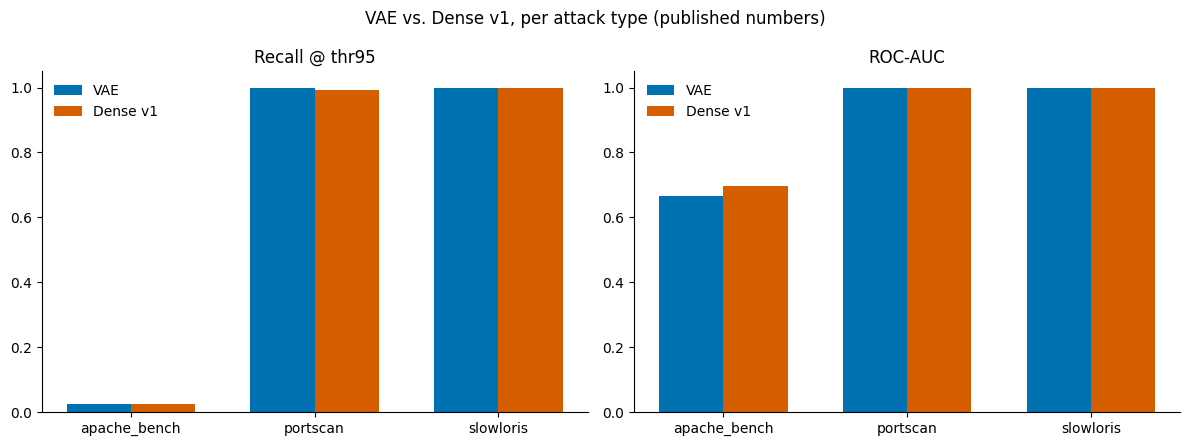

,macro_recall,macro_f1
model,,
Dense v1,0.673104,0.540116
VAE,0.674833,0.536175


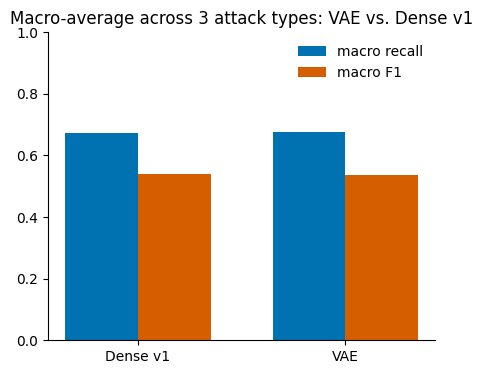

Neither model is meaningfully more balanced -- both show near-perfect portscan/slowloris recall and near-total apache_bench misses; see comparison_vae_vs_dense.md for the full discussion.


In [8]:
vae_single = pd.read_csv(os.path.join(REPORT_DIR, "01_single_attack_type", "vae", "results.csv"))
dense_single = pd.read_csv(os.path.join(DENSE_DIR, "results_single_attack_type_dense.csv"))

comparison = vae_single[["attack_type", "roc_auc_mean", "attack_recall_mean", "f1_mean"]].copy()
comparison["model"] = "VAE"
dense_comp = dense_single[["attack_type", "roc_auc_mean", "attack_recall_mean", "f1_mean"]].copy()
dense_comp["model"] = "Dense v1"
comparison = pd.concat([comparison, dense_comp], ignore_index=True)
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
types = vae_single["attack_type"].tolist()
x = np.arange(len(types)); width = 0.35
for ax, metric, title in [(axes[0], "attack_recall_mean", "Recall @ thr95"), (axes[1], "roc_auc_mean", "ROC-AUC")]:
    vae_vals = comparison[comparison["model"] == "VAE"].set_index("attack_type").loc[types, metric]
    dense_vals = comparison[comparison["model"] == "Dense v1"].set_index("attack_type").loc[types, metric]
    ax.bar(x - width/2, vae_vals, width, label="VAE", color="#0072B2")
    ax.bar(x + width/2, dense_vals, width, label="Dense v1", color="#D55E00")
    ax.set_xticks(x); ax.set_xticklabels(types)
    ax.set_ylim(0, 1.05); ax.set_title(title); ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("VAE vs. Dense v1, per attack type (published numbers)")
fig.tight_layout()
plt.show()

macro_recall = comparison.groupby("model")["attack_recall_mean"].mean()
macro_f1 = comparison.groupby("model")["f1_mean"].mean()
macro_table = pd.DataFrame({"macro_recall": macro_recall, "macro_f1": macro_f1})
display(macro_table)

fig, ax = plt.subplots(figsize=(5, 4))
x = np.arange(2); width = 0.35
ax.bar(x - width/2, macro_table["macro_recall"], width, label="macro recall", color="#0072B2")
ax.bar(x + width/2, macro_table["macro_f1"], width, label="macro F1", color="#D55E00")
ax.set_xticks(x); ax.set_xticklabels(macro_table.index)
ax.set_ylim(0, 1.0); ax.legend(frameon=False)
ax.set_title("Macro-average across 3 attack types: VAE vs. Dense v1")
ax.spines[["top", "right"]].set_visible(False)
plt.show()
print("Neither model is meaningfully more balanced -- both show near-perfect portscan/slowloris recall "
      "and near-total apache_bench misses; see comparison_vae_vs_dense.md for the full discussion.")